# AI Powered Anomaly detection

### Goals -
1. Detecting anomalies in the dataset.
3. Combining the 3 different datasets in one dataset.
4. Flagging unusual salaries as 0 and 1.
5. Training the model on dataset.
6. Creating the core payroll modules

## Complete workflow

Following complete workflow will followed in iterative manner till the conclusions and model is formed:-
1. **Data understanding** - Understanding the data, meanings, columns in dataset, checking missing and duplicate values.
1. **Data Analysis and visualization** - Analyzing the distribution of columns of the data, getting the insights of the data, Visualizing the relationships between features, outliers through different plots.
2. **Data Preprocessing** - Cleaning the data, Adding new required features, changing the datatype of the features.
4. **Feature encoding and scaling** - Converting the object data type features into catergoical numeric data, standardizing data using standardscalar.
6. **Model building and Anomaly detection** - Performing anomaly detection on the final data and flag unusual salaries.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Understanding
Understanding the data, meanings, columns in dataset, checking missing and duplicate values.

In [88]:
employee_df = pd.read_csv("./data/zenvy_employees.csv")
attendance_df = pd.read_csv("./data/zenvy_attendance.csv")
payroll_df = pd.read_csv("./data/zenvy_payroll.csv")

### Understanding Employees dataset

In [89]:
employee_df.head()

,employee_id,employee_name,department,designation,base_salary,joining_date
0,1001,Aarav,IT,Developer,50000,2023-01-31
1,1002,Diya,HR,HR Executive,35000,2023-02-28
2,1003,Rohan,Finance,Accountant,40000,2023-03-31
3,1004,Sneha,IT,Developer,55000,2023-04-30
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31


In [90]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   employee_id    20 non-null     int64 
 1   employee_name  20 non-null     object
 2   department     20 non-null     object
 3   designation    20 non-null     object
 4   base_salary    20 non-null     int64 
 5   joining_date   20 non-null     object
dtypes: int64(2), object(4)
memory usage: 1.1+ KB


In [91]:
employee_df.describe()

,employee_id,base_salary
count,20.00000,20.000000
mean,1010.50000,53950.000000
std,5.91608,20011.772851
min,1001.00000,30000.000000
25%,1005.75000,35750.000000
50%,1010.50000,51000.000000
75%,1015.25000,71250.000000
max,1020.00000,90000.000000


In [92]:
employee_df.isna().sum()

employee_id      0
employee_name    0
department       0
designation      0
base_salary      0
joining_date     0
dtype: int64

In [93]:
employee_df.shape

(20, 6)

In [94]:
employee_df.duplicated().sum()

np.int64(0)

* Employee.csv doesn't have missing values.
* categorical values - Department, designation, joining_date, employee_id.
* numerical values (int) - base_salary.
* mixed values - employee_name.
* employee_name is of object data type.
* There are no duplicate values.
* Shape of the data is (20, 6) i.e. 20 rows, 6 columns.

### Understanding attendance dataset

In [95]:
attendance_df.head()

,employee_id,working_days,present_days,overtime_hours
0,1001,22,20,5
1,1002,22,21,2
2,1003,22,19,0
3,1004,22,22,8
4,1005,22,20,4


In [96]:
attendance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   employee_id     20 non-null     int64
 1   working_days    20 non-null     int64
 2   present_days    20 non-null     int64
 3   overtime_hours  20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes


In [97]:
attendance_df.describe()

,employee_id,working_days,present_days,overtime_hours
count,20.00000,20.0,20.000000,20.000000
mean,1010.50000,22.0,20.600000,4.400000
std,5.91608,0.0,1.095445,3.377947
min,1001.00000,22.0,19.000000,0.000000
25%,1005.75000,22.0,20.000000,2.000000
50%,1010.50000,22.0,21.000000,4.000000
75%,1015.25000,22.0,21.250000,6.250000
max,1020.00000,22.0,22.000000,12.000000


In [98]:
attendance_df.isna().sum()

employee_id       0
working_days      0
present_days      0
overtime_hours    0
dtype: int64

In [99]:
attendance_df.duplicated().sum()

np.int64(0)

In [100]:
attendance_df.shape

(20, 4)

* Attendance.csv doesn't have missing and duplicate values.
* Every feature is of integer data types.
* shape of data is (20, 4) i.e. 20 rows and 4 columns.

### Understanding payroll dataset

In [101]:
payroll_df.head()

,employee_id,gross_salary,tax_deduction,pf_deduction,net_salary
0,1001,52500,5000.0,2500.0,45000.0
1,1002,36000,3500.0,1750.0,30750.0
2,1003,40000,4000.0,2000.0,34000.0
3,1004,59000,5500.0,2750.0,50750.0
4,1005,32000,3000.0,1500.0,27500.0


In [102]:
payroll_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   employee_id    20 non-null     int64  
 1   gross_salary   20 non-null     int64  
 2   tax_deduction  20 non-null     float64
 3   pf_deduction   20 non-null     float64
 4   net_salary     20 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 932.0 bytes


In [103]:
payroll_df.describe()

,employee_id,gross_salary,tax_deduction,pf_deduction,net_salary
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,1010.50000,56150.000000,5395.000000,2697.500000,48057.500000
std,5.91608,21156.745845,2001.177285,1000.588643,18161.347584
min,1001.00000,32000.000000,3000.000000,1500.000000,27500.000000
25%,1005.75000,36375.000000,3575.000000,1787.500000,31012.500000
50%,1010.50000,54000.000000,5100.000000,2550.000000,46350.000000
75%,1015.25000,72500.000000,7125.000000,3562.500000,61812.500000
max,1020.00000,96000.000000,9000.000000,4500.000000,82500.000000


In [104]:
payroll_df.isna().sum()

employee_id      0
gross_salary     0
tax_deduction    0
pf_deduction     0
net_salary       0
dtype: int64

In [105]:
payroll_df.duplicated().sum()

np.int64(0)

In [106]:
payroll_df.shape

(20, 5)

* Payroll.csv dataset doesn't have missing and duplicate values.
* Numerical datatype - gross_salary, tax_deduction, pf_deduction, net_salary.
* categorical datatype - employee_id.
* shape of payroll dataset is (20, 5) i.e. 20 rows and 5 columns.

**Now we have done the basic data analysis, let's move ahead to data visualization**

## Data Analysis, visualization and preprocessing

Following will be iteratively:
* Analyzing the distribution of columns of the data, getting the insights of the data.
* Visualizing the relationships between features, outliers through different plots.
* Cleaning the data, Adding new required features, changing the datatype of the features.

In [107]:
plt.style.use('ggplot')

### Data analysis of payroll dataset

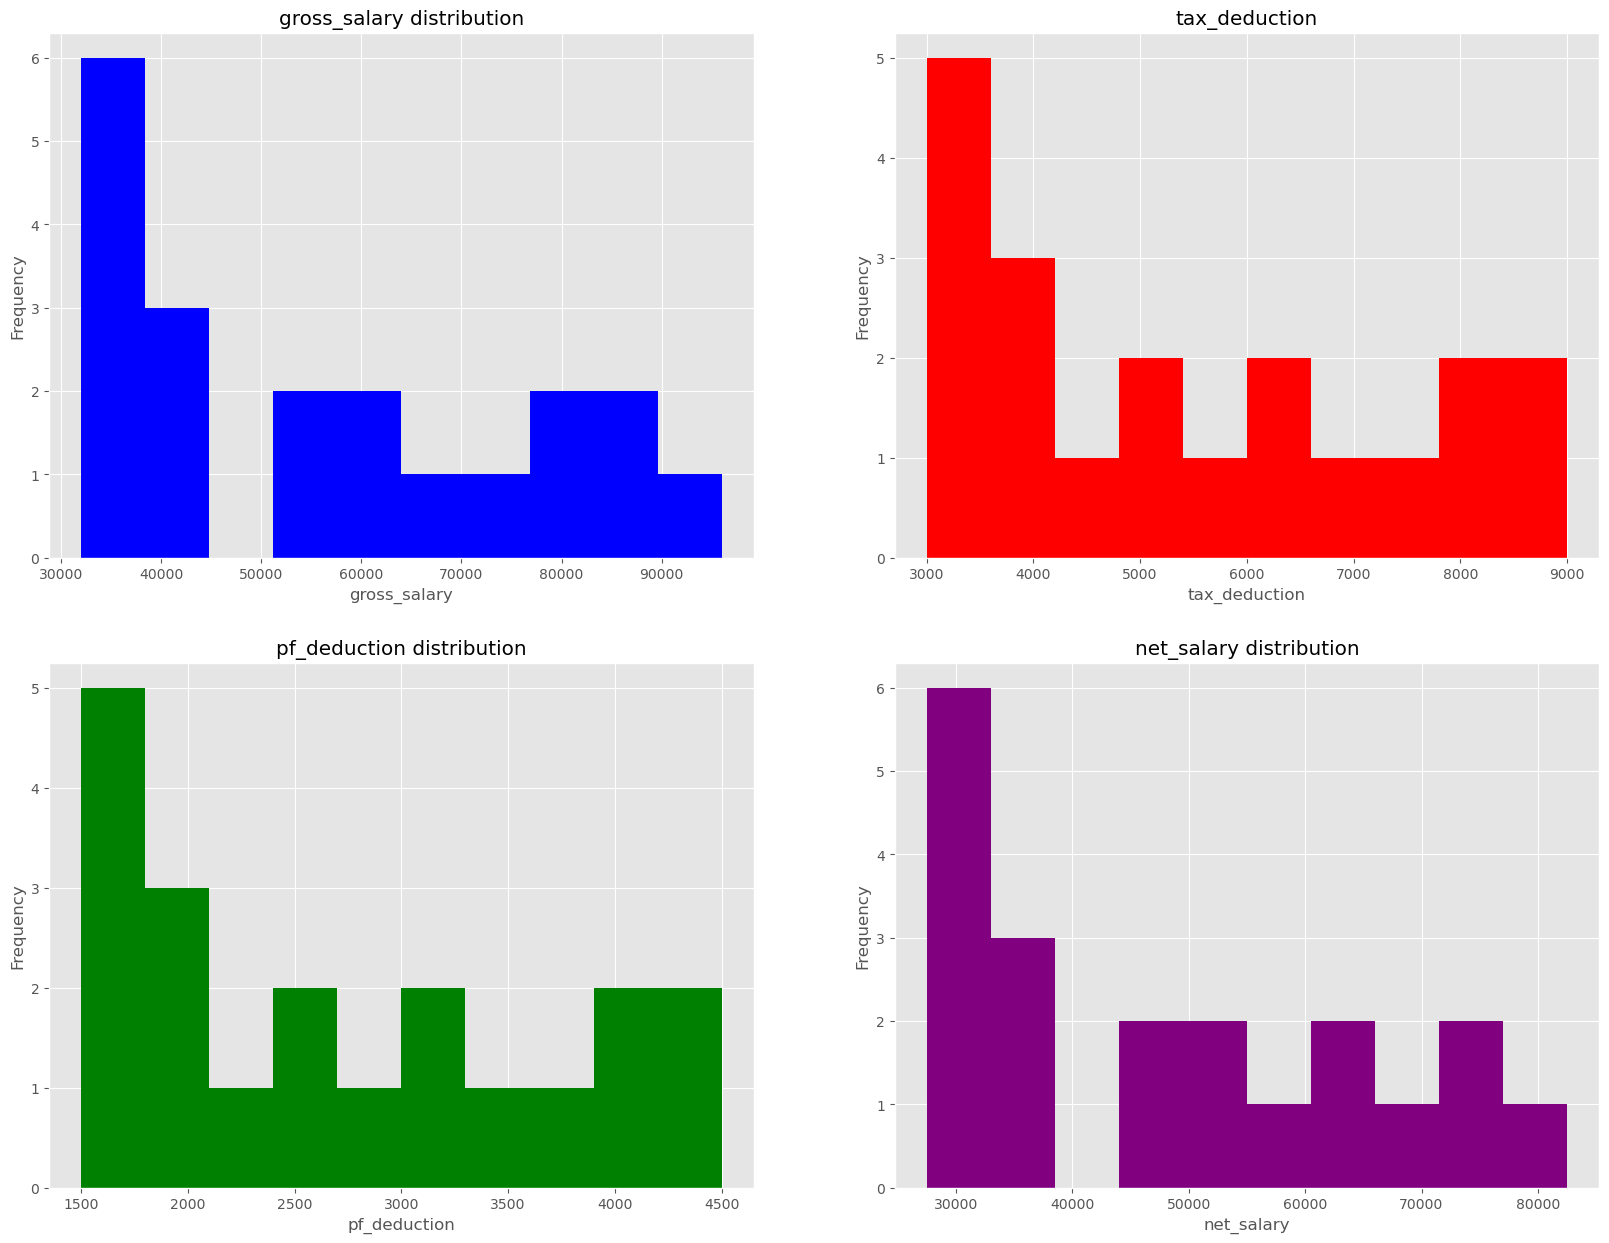

In [108]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))

#plotting the histogram for all the features of payroll dataset
ax1.hist(payroll_df['gross_salary'], color = "blue");
ax1.set(title = "gross_salary distribution",
        xlabel = "gross_salary",
        ylabel = "Frequency")

ax2.hist(payroll_df['tax_deduction'], color = "red");
ax2.set(title = "tax_deduction",
        xlabel = "tax_deduction",
        ylabel = "Frequency")

ax3.hist(payroll_df['pf_deduction'], color = "green");
ax3.set(title = "pf_deduction distribution",
        xlabel = "pf_deduction",
        ylabel = "Frequency")

ax4.hist(payroll_df['net_salary'], color = "purple");
ax4.set(title = "net_salary distribution",
        xlabel = "net_salary",
        ylabel = "Frequency")

plt.show()

**Conclusions:**
* gross_salary and net_salary show break in their distribution.
* All the features are left skewed with spikes at certain values.

**Since all the column datatypes are numerical, so we can analyze the relationship, correlation between them.**

<Axes: >

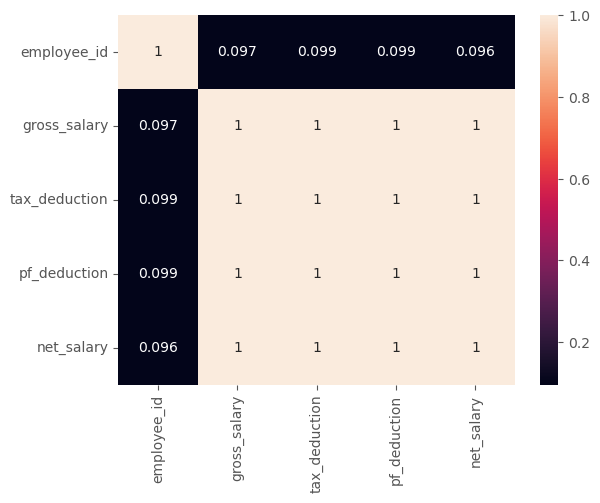

In [109]:
payroll_corr_matrix  = payroll_df.corr()
sns.heatmap(payroll_corr_matrix, annot=True)

<Axes: ylabel='net_salary'>

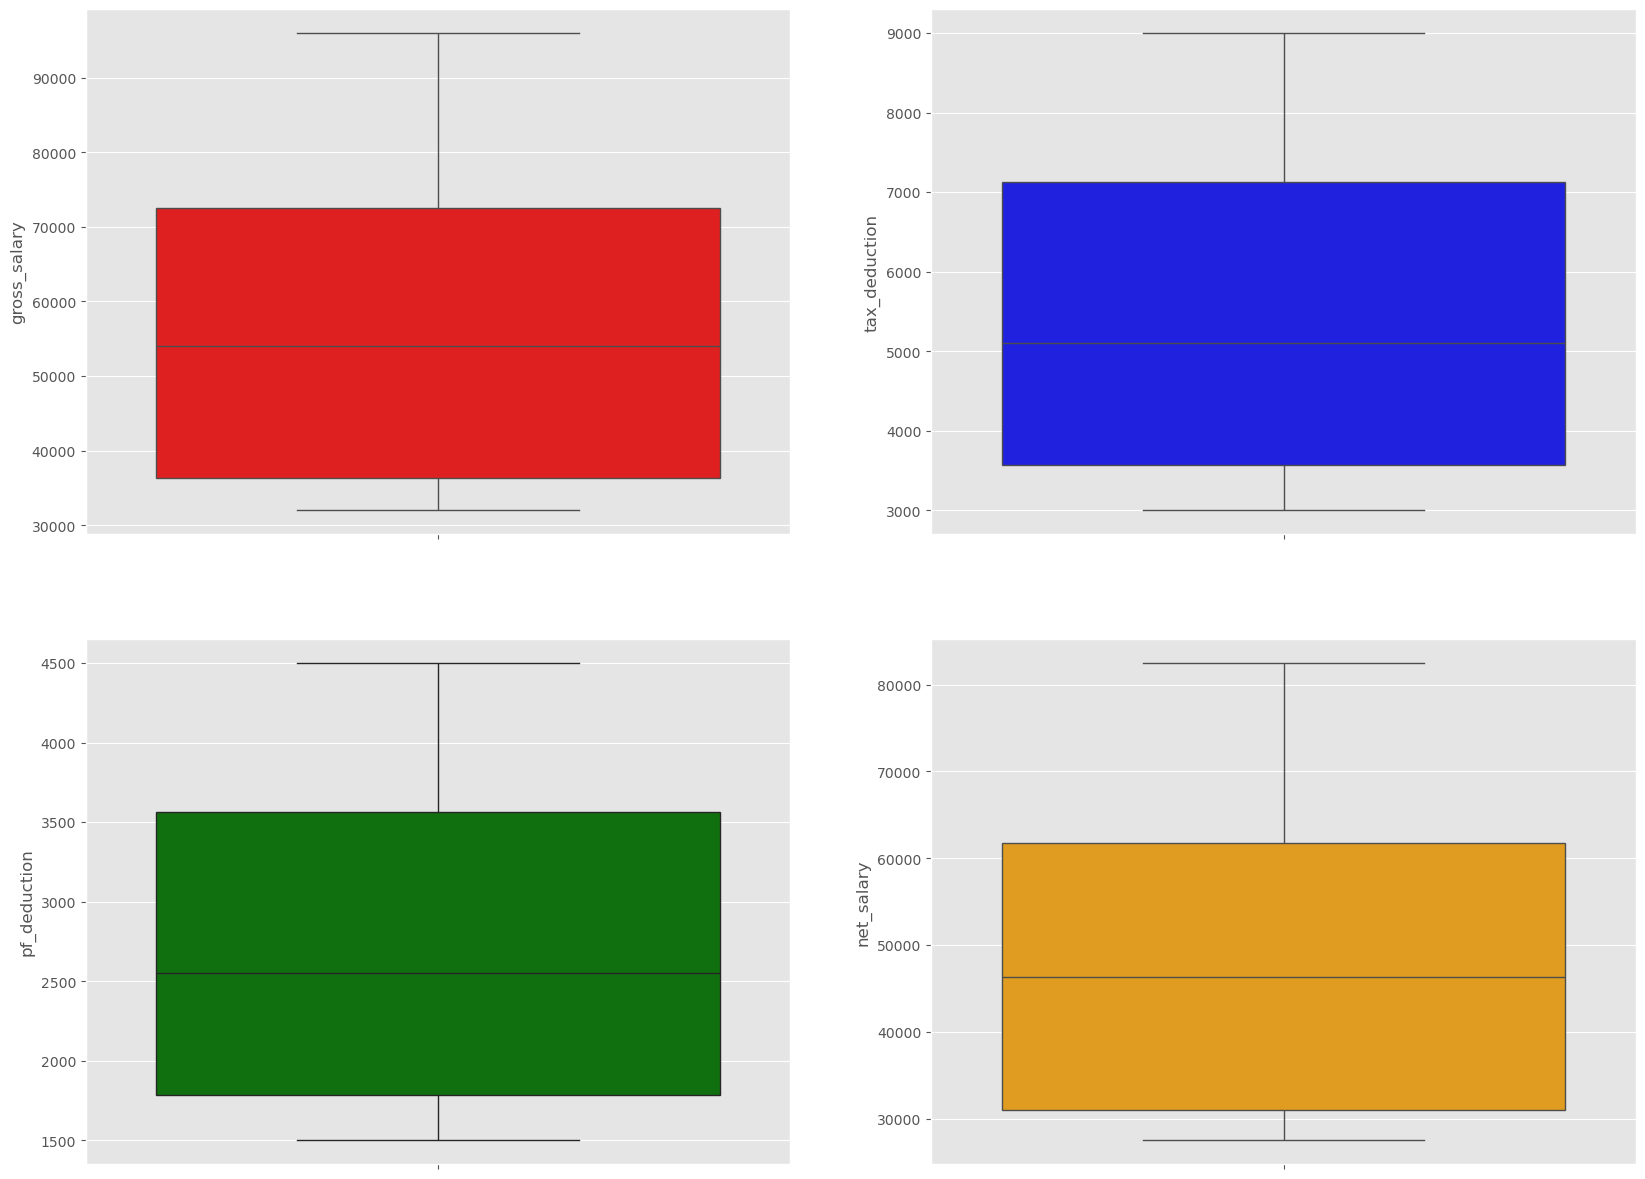

In [110]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))

#boxplot to know the outliers if existed in the dataset.
sns.boxplot(payroll_df['gross_salary'], ax=ax1, color='red')
sns.boxplot(payroll_df['tax_deduction'], ax=ax2, color='blue')
sns.boxplot(payroll_df['pf_deduction'], ax=ax3, color='green')
sns.boxplot(payroll_df['net_salary'], ax=ax4, color='orange')

**Conclusion:** \
There are no outliers in any feature

### Data analysis of attendance dataset

In [111]:
attendance_df.head()

,employee_id,working_days,present_days,overtime_hours
0,1001,22,20,5
1,1002,22,21,2
2,1003,22,19,0
3,1004,22,22,8
4,1005,22,20,4


<Axes: xlabel='overtime_hours', ylabel='Count'>

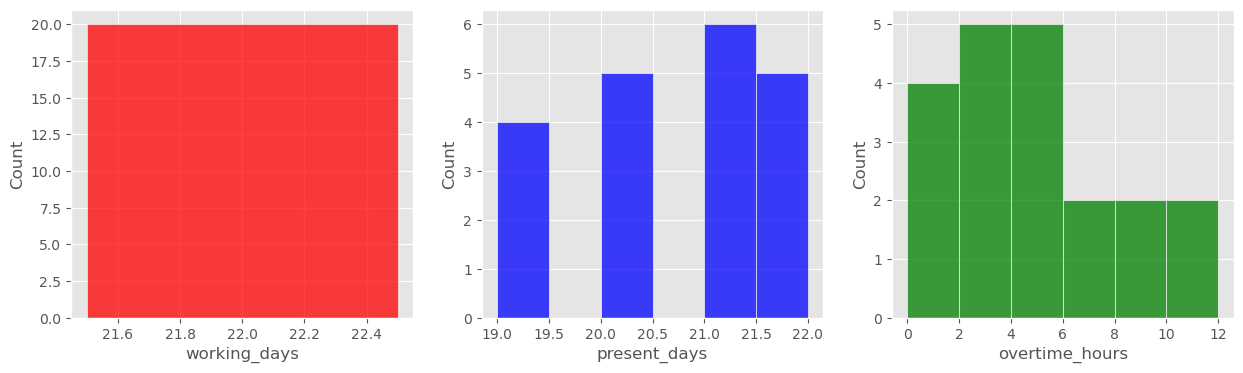

In [112]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

#histogram of the features of attendance dataset
sns.histplot(attendance_df['working_days'], ax=ax1, color='red')
sns.histplot(attendance_df['present_days'], ax=ax2, color='blue')
sns.histplot(attendance_df['overtime_hours'], ax=ax3, color='green')

<Axes: >

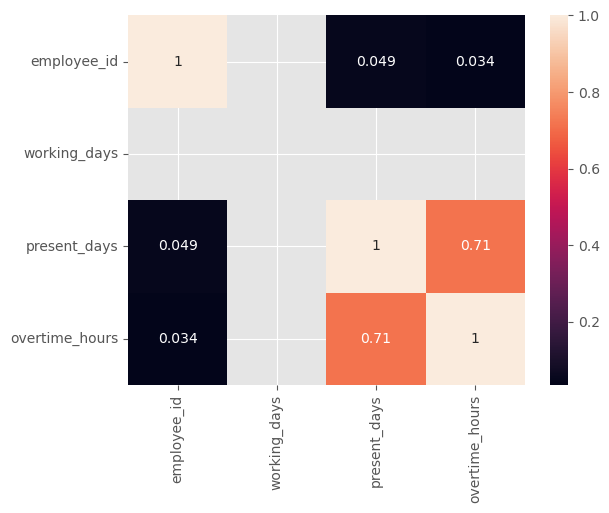

In [113]:
attendance_corr_matrix = attendance_df.corr()
sns.heatmap(attendance_corr_matrix, annot=True)

<Axes: ylabel='overtime_hours'>

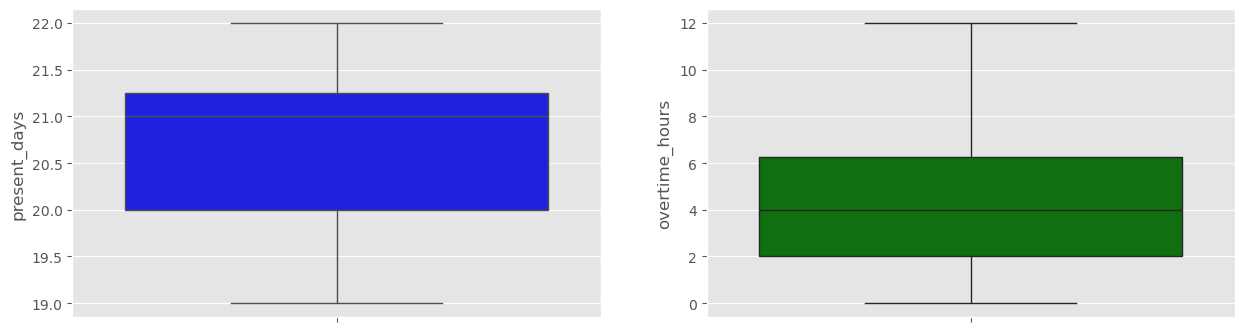

In [114]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,4))

#boxplot to get the outliers in the features.
sns.boxplot(attendance_df['present_days'], ax=ax1, color='blue')
sns.boxplot(attendance_df['overtime_hours'], ax=ax2, color='green')

**Conclusions**\
There are no outliers in any features of attendance dataset.

### Data analysis of employee_dataset

In [115]:
employee_df.head()

,employee_id,employee_name,department,designation,base_salary,joining_date
0,1001,Aarav,IT,Developer,50000,2023-01-31
1,1002,Diya,HR,HR Executive,35000,2023-02-28
2,1003,Rohan,Finance,Accountant,40000,2023-03-31
3,1004,Sneha,IT,Developer,55000,2023-04-30
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31


<Axes: ylabel='base_salary'>

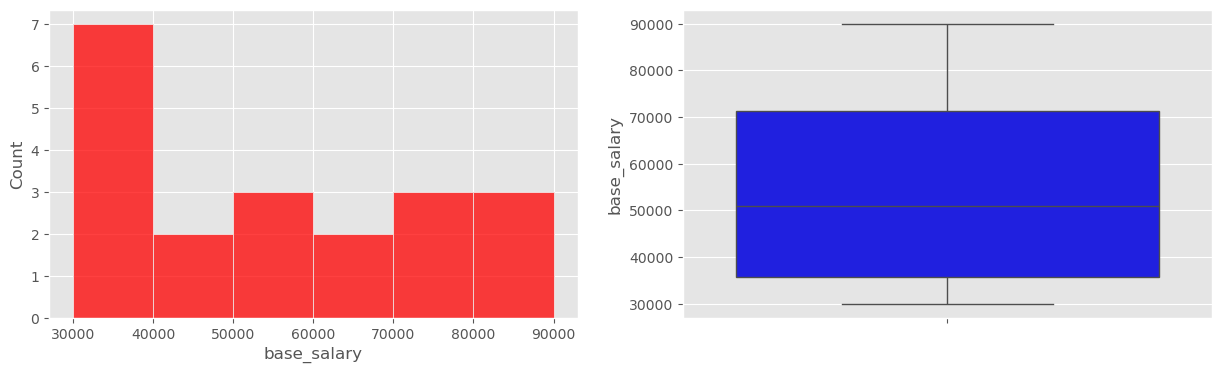

In [116]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(employee_df['base_salary'], ax=ax1, color='red')
sns.boxplot(employee_df['base_salary'], ax=ax2, color='blue')

**Merging 3 CSV files into one** because this will help me in better predictions, understanding the relations between the features, and creating new required features.

In [117]:
complete_dataset = employee_df.merge(attendance_df, on="employee_id", how="inner")
complete_dataset = complete_dataset.merge(payroll_df, on="employee_id", how="inner")
complete_dataset.to_csv("./data/combined_dataset.csv", index=False)

In [118]:
complete_dataset.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,tax_deduction,pf_deduction,net_salary
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,5000.0,2500.0,45000.0
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,3500.0,1750.0,30750.0
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,4000.0,2000.0,34000.0
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,5500.0,2750.0,50750.0
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,3000.0,1500.0,27500.0


In [119]:
complete_dataset['isPfFlag'] = (complete_dataset['pf_deduction'] == 0.12*complete_dataset['base_salary'])
complete_dataset['isPfFlag'][complete_dataset['isPfFlag']==True].count()

np.int64(0)

**Since the count is 0 so it means that pf_deductions is not the standard 12% of base salary, so let's check it out what would the maximum pf_deductions taken.**

In [120]:
complete_dataset['pf_percentage'] = (complete_dataset['pf_deduction'] / complete_dataset['base_salary'])*100

<Axes: ylabel='pf_percentage'>

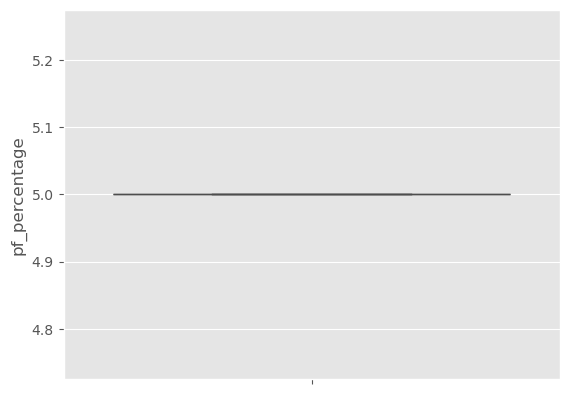

In [121]:
sns.boxplot(complete_dataset['pf_percentage'], color='blue')

In [122]:
complete_dataset['pf_percentage'].describe()

count    20.0
mean      5.0
std       0.0
min       5.0
25%       5.0
50%       5.0
75%       5.0
max       5.0
Name: pf_percentage, dtype: float64

**This comes to conclusion that pf_deduction is 5% of base salary as the mean, minimum and maximum, and there is no anomalies in pf_deductions.**

* No. of Working days = 22 
* No.of working hours on average = 8 hours (assuming 9am - 5pm)
* so total working hours/month = 22*8 = 176.
* hourly rate = base_Salary / total working hours.

In [123]:
complete_dataset['overtime_pay'] = complete_dataset['overtime_hours']*complete_dataset['base_salary']/176


In [124]:
complete_dataset['updated_net_salary'] = complete_dataset['net_salary'] + complete_dataset['overtime_pay']
complete_dataset['average_salary'] = complete_dataset.groupby('designation')['base_salary'].transform('mean')
complete_dataset['salary_deviation'] = complete_dataset['base_salary'] - complete_dataset['average_salary']
complete_dataset['overtime_pay_per_hour'] = complete_dataset['overtime_pay']/(complete_dataset['overtime_hours']+1)
complete_dataset.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,tax_deduction,pf_deduction,net_salary,isPfFlag,pf_percentage,overtime_pay,updated_net_salary,average_salary,salary_deviation,overtime_pay_per_hour
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,5000.0,2500.0,45000.0,False,5.0,1420.454545,46420.454545,52333.333333,-2333.333333,236.742424
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,3500.0,1750.0,30750.0,False,5.0,397.727273,31147.727273,36333.333333,-1333.333333,132.575758
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,4000.0,2000.0,34000.0,False,5.0,0.000000,34000.000000,41000.000000,-1000.000000,0.000000
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,5500.0,2750.0,50750.0,False,5.0,2500.000000,53250.000000,52333.333333,2666.666667,277.777778
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,3000.0,1500.0,27500.0,False,5.0,681.818182,28181.818182,31000.000000,-1000.000000,136.363636


Now, what I actually want to do is to check whether the net_salary given to employee includes the correct no of present days and overtime pay or not. \
For that I will follow the following steps:
1. Calculate the LOP days.
2. Calculate the **total paid days** which will equal to **(present_days + paid_leaves)**
3. Calculate the **pay_per_day** which will be equal to **(base_salary / no of working days)** (taken base_salary because it is fixed for individual)
4. Calculate the **earned_base** which will be equal to **pay_per_day * no of total paid days**.
5. Calculate the **expected gross** which will be equal to **earned_base + Overtime_pay**
6. Calculate the **expected net** which will be euqal to **expected_gross - (tax_deduction + pf_deduction)**
7. Calculate the **net_diff** which will be equal to **updated_net_salary - expected_net**

if **absolute of net_diff > tolerance** (I will define later) then **anomaly** else no anomaly.
But since we can also see a lot of deviations in base salary from average of designation, so we need to take it also in considerations for anomaly. Which I will do later in this notebook later in anomaly detection.

Let's assume that maximum no of paid leaves that employee can take is **3 leaves** in 22 days.

In [125]:
complete_dataset['LOP_days'] = complete_dataset['working_days'] - (complete_dataset['present_days'] + 3)
complete_dataset['LOP_days']

0    -1
1    -2
2     0
3    -3
4    -1
5    -2
6    -3
7    -1
8    -2
9     0
10   -3
11   -2
12   -1
13    0
14   -2
15   -3
16   -1
17   -2
18    0
19   -3
Name: LOP_days, dtype: int64

In [126]:
complete_dataset['paid_leaves'] = complete_dataset['present_days'] + 3
complete_dataset['pay_per_day'] = complete_dataset['base_salary'] / complete_dataset['working_days']
complete_dataset['earned_base'] = complete_dataset['pay_per_day'] * complete_dataset['paid_leaves']
complete_dataset['expected_gross_salary'] = complete_dataset['earned_base'] + complete_dataset['overtime_pay']
complete_dataset['expected_net'] = complete_dataset['expected_gross_salary'] - (complete_dataset['tax_deduction'] + complete_dataset['pf_deduction']) 
complete_dataset['salary_diff'] = complete_dataset['updated_net_salary'] - complete_dataset['expected_net']
complete_dataset.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,average_salary,salary_deviation,overtime_pay_per_hour,LOP_days,paid_leaves,pay_per_day,earned_base,expected_gross_salary,expected_net,salary_diff
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,52333.333333,-2333.333333,236.742424,-1,23,2272.727273,52272.727273,53693.181818,46193.181818,227.272727
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,36333.333333,-1333.333333,132.575758,-2,24,1590.909091,38181.818182,38579.545455,33329.545455,-2181.818182
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,41000.000000,-1000.000000,0.000000,0,22,1818.181818,40000.000000,40000.000000,34000.000000,0.000000
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,52333.333333,2666.666667,277.777778,-3,25,2500.000000,62500.000000,65000.000000,56750.000000,-3500.000000
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,31000.000000,-1000.000000,136.363636,-1,23,1363.636364,31363.636364,32045.454545,27545.454545,636.363636


**Now Let's visualize the distributions, relationships, outliers in the new columns created recently using plots.** \
For this let's first check all the columns that we have.

In [127]:
complete_dataset.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff'],
      dtype='object')

<Axes: xlabel='salary_deviation', ylabel='Count'>

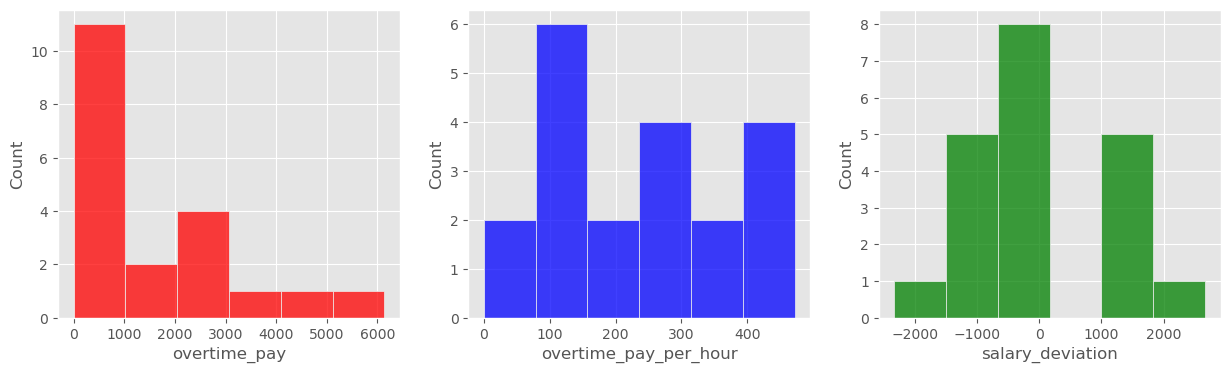

In [128]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(complete_dataset['overtime_pay'], ax=ax1, color='red')
sns.histplot(complete_dataset['overtime_pay_per_hour'], ax=ax2, color='blue')
sns.histplot(complete_dataset['salary_deviation'], ax=ax3, color='green')

**Conclusions**
* The data is not normally distributed.
* There are spikes at certain values.

<Axes: ylabel='salary_deviation'>

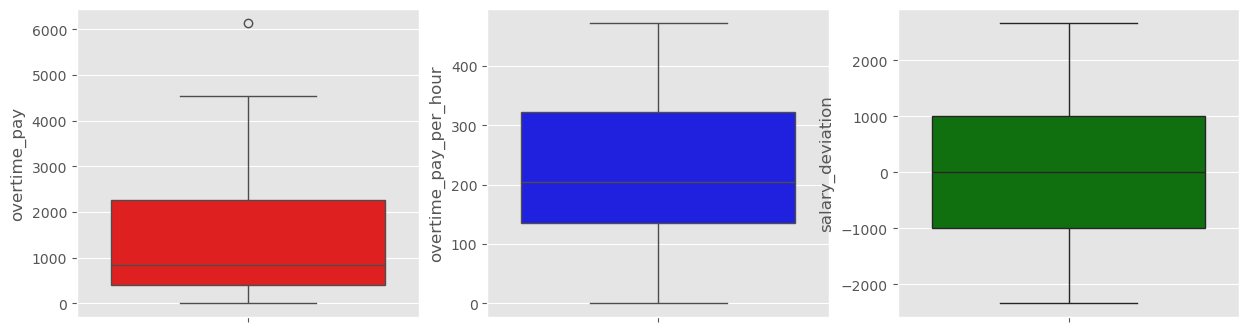

In [129]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

sns.boxplot(complete_dataset['overtime_pay'], ax=ax1, color='red')
sns.boxplot(complete_dataset['overtime_pay_per_hour'], ax=ax2, color='blue')
sns.boxplot(complete_dataset['salary_deviation'], ax=ax3, color='green')

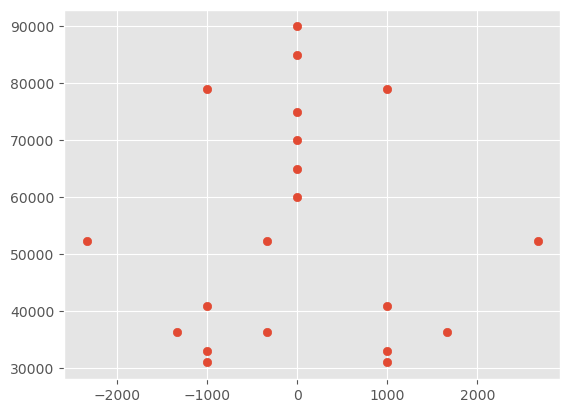

In [130]:
plt.scatter(complete_dataset['salary_deviation'], complete_dataset['average_salary'])

## Feature Selection and feature scaling

I will convert the categorical values to numeric values in order to easy for model training using OneHotEncoder

In [131]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import IsolationForest

encoder = LabelEncoder()
complete_dataset['department_encoded'] = encoder.fit_transform(complete_dataset['department'])
complete_dataset['designation_encoded'] = encoder.fit_transform(complete_dataset['designation'])

In [132]:
complete_dataset.columns

Index(['employee_id', 'employee_name', 'department', 'designation',
       'base_salary', 'joining_date', 'working_days', 'present_days',
       'overtime_hours', 'gross_salary', 'tax_deduction', 'pf_deduction',
       'net_salary', 'isPfFlag', 'pf_percentage', 'overtime_pay',
       'updated_net_salary', 'average_salary', 'salary_deviation',
       'overtime_pay_per_hour', 'LOP_days', 'paid_leaves', 'pay_per_day',
       'earned_base', 'expected_gross_salary', 'expected_net', 'salary_diff',
       'department_encoded', 'designation_encoded'],
      dtype='object')

## Model Training and Building

In [133]:
features = [
    "base_salary",
    "present_days",
    "overtime_pay_per_hour",
    "LOP_days",
    "department_encoded",
    "designation_encoded",
    "salary_diff",
    'salary_deviation',
    'earned_base',
    "expected_gross_salary",
    "expected_net",
    "updated_net_salary",
    'overtime_hours', 
    'overtime_pay',
]

X = complete_dataset[features]

In [134]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [135]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # assume 5% anomalies
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [136]:
complete_dataset["anomaly_score"] = model.decision_function(X_scaled)
complete_dataset["anomaly_flag"] = model.predict(X_scaled)
complete_dataset.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,paid_leaves,pay_per_day,earned_base,expected_gross_salary,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,23,2272.727273,52272.727273,53693.181818,46193.181818,227.272727,2,1,0.046188,1
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,24,1590.909091,38181.818182,38579.545455,33329.545455,-2181.818182,1,3,0.096786,1
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,22,1818.181818,40000.000000,40000.000000,34000.000000,0.000000,0,0,0.056792,1
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,25,2500.000000,62500.000000,65000.000000,56750.000000,-3500.000000,2,1,0.055231,1
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,23,1363.636364,31363.636364,32045.454545,27545.454545,636.363636,4,7,0.037363,1


In [137]:
complete_dataset['anomaly_flag'].value_counts()

anomaly_flag
 1    19
-1     1
Name: count, dtype: int64

In [138]:
anomalies = complete_dataset[complete_dataset["anomaly_flag"] == -1]
anomalies.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,paid_leaves,pay_per_day,earned_base,expected_gross_salary,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag
10,1011,Siddharth,IT,Tech Lead,90000,2023-11-30,22,22,12,96000,...,25,4090.909091,102272.727273,108409.090909,94909.090909,-6272.727273,2,11,-0.071296,-1


In [139]:
no_anomalies = complete_dataset[complete_dataset["anomaly_flag"] == 1]
no_anomalies.head()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,paid_leaves,pay_per_day,earned_base,expected_gross_salary,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag
0,1001,Aarav,IT,Developer,50000,2023-01-31,22,20,5,52500,...,23,2272.727273,52272.727273,53693.181818,46193.181818,227.272727,2,1,0.046188,1
1,1002,Diya,HR,HR Executive,35000,2023-02-28,22,21,2,36000,...,24,1590.909091,38181.818182,38579.545455,33329.545455,-2181.818182,1,3,0.096786,1
2,1003,Rohan,Finance,Accountant,40000,2023-03-31,22,19,0,40000,...,22,1818.181818,40000.000000,40000.000000,34000.000000,0.000000,0,0,0.056792,1
3,1004,Sneha,IT,Developer,55000,2023-04-30,22,22,8,59000,...,25,2500.000000,62500.000000,65000.000000,56750.000000,-3500.000000,2,1,0.055231,1
4,1005,Karan,Sales,Sales Exec,30000,2023-05-31,22,20,4,32000,...,23,1363.636364,31363.636364,32045.454545,27545.454545,636.363636,4,7,0.037363,1


In [140]:
no_anomalies.tail()

,employee_id,employee_name,department,designation,base_salary,joining_date,working_days,present_days,overtime_hours,gross_salary,...,paid_leaves,pay_per_day,earned_base,expected_gross_salary,expected_net,salary_diff,department_encoded,designation_encoded,anomaly_score,anomaly_flag
15,1016,Isha,IT,Developer,52000,2024-04-30,22,22,7,55500,...,25,2363.636364,59090.909091,61159.090909,53359.090909,-3590.909091,2,1,0.064717,1
16,1017,Manish,Marketing,Marketing Exec,34000,2024-05-31,22,20,2,35000,...,23,1545.454545,35545.454545,35931.818182,30831.818182,-545.454545,3,5,0.101374,1
17,1018,Ritu,HR,HR Executive,38000,2024-06-30,22,21,4,40000,...,24,1727.272727,41454.545455,42318.181818,36618.181818,-1454.545455,1,3,0.080506,1
18,1019,Nikhil,Finance,Accountant,42000,2024-07-31,22,19,0,42000,...,22,1909.090909,42000.000000,42000.000000,35700.000000,0.000000,0,0,0.049386,1
19,1020,Priya,IT,Senior Developer,78000,2024-08-31,22,22,9,82500,...,25,3545.454545,88636.363636,92625.000000,80925.000000,-6136.363636,2,10,0.048675,1


In [141]:
complete_dataset['salary_deviation_flag'] = (abs(complete_dataset['salary_deviation']) <= 1000).astype(int)
complete_dataset['salary_deviation_flag'].value_counts()

salary_deviation_flag
1    16
0     4
Name: count, dtype: int64

#### Some conclusions:
* 1 (Within tolerance) -> 16
* 0 (Beyond tolerance) -> 4

It shows that :
1. 16 out of 20 (80%) employees base_salary is close to designation average.
2. Only 4 out of 20 (20%) employees base_salary is outside tolerance which is quite acceptable and reasonable.

In [142]:
complete_dataset['salary_diff_flag'] = (abs(complete_dataset['salary_diff']) <= 1000).astype(int)
complete_dataset['salary_diff_flag'].value_counts()

salary_diff_flag
0    14
1     6
Name: count, dtype: int64

#### Some conclusions:
* 1 (within tolerance) -> 6
* 0 (beyond tolerance) -> 14

It shows that :
1. 6 out of 20 (30%) employees have expected_net_salary close to net_salary.
2. 14 out of 20 (70%) employees have large differences between expected_net_salary and net_salary.

#### Isolation forest result:
* 1 anomaly detected i.e Isolation forest only able to find one rare combination of
  1. salary deviation, difference between expected_net_salary and net_salary.
  2. Possible OT rare pattern.

# Conclusion: 

What I considered as anomaly are:
* if base_salary deviation from designation average, i.e. ${abs(salary\_deviation)}$ > 1000
* if difference between expected_net_salary and net_salary, i.e. ${abs(salary\_diff)}$ >= 1000

Following conclusions can be made from above analysis and model results :
1. Tolerance based models showed that there are **multiple employees** whose **base salary close to designation average**, but still there were **large no of employees** whose **net salary showed a large positive or negative deviation or difference from expected_net_salary**.
2. Despite having large positive or negative devitation of net_salary from expected_net_salary for many employees, **model still give result of only 1 employee as anomaly** which indicates dataset is the **biased data where anomalies are present in the majority when it should be present as rare**.

#### How can we improve it to improve the predictions:
1. Taking the large, balanced data that contains anomalies as a rare points.
2. using rule based checks as primary controls
3. using ML as second alert system.
4. Fixing systematic payroll logic.

In [143]:
complete_dataset.to_csv("./data/combined_dataset.csv", index=False)